# Supplementary Figure S12: Tripartite Information in Undecorated and Decorated Graphs

Supplementary Figure S12 combines the tripartite-information comparisons for undecorated and decorated graph states.  Each panel compares the Gaussian-state tripartite information with the midpoint RT ansatz for the same sampled boundary triplets.

This figure includes:

* (a) undecorated MERA state versus RT tripartite information
* (b) undecorated regular hyperbolic $\{3,7\}$ state versus RT tripartite information
* (c) undecorated regular hyperbolic $\{3,8\}$ state versus RT tripartite information
* (d) decorated MERA state versus RT tripartite information
* (e) decorated regular hyperbolic $\{3,7\}$ state versus RT tripartite information
* (f) decorated regular hyperbolic $\{3,8\}$ state versus RT tripartite information


## Import Dependencies and Set Parameters

Load plotting defaults, configure the shared triplet-sampling parameters, and define the three graph geometries used in both rows.

In [1]:
%load_ext autoreload
%autoreload 2

import hashlib
import json
import os
import pickle
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "global_figure_settings.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

os.environ.setdefault("MPLCONFIGDIR", str(Path("outputs/mplconfig").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.transforms import Bbox
from tqdm.auto import tqdm

import loadconfig as loco
from graph2grav import plotting
from graph2grav import tree_wormhole_knockout as twk
from graph2grav.figure_hashing import save_figure_with_hash
from graph2grav.tripartite_analysis import evaluate_tripartite_dataset, sample_boundary_triplets

config = loco.reload()
plt.rcParams.update({"figure.dpi": 120})
subfigure_label_fontsize = config["subfigure-label"]["font"]["size"]

INEQUALITY_STYLE = config["inequality-diagnostics"]
SATISFIED_POINT_STYLE = INEQUALITY_STYLE["points"]["satisfied"]
VIOLATED_POINT_STYLE = INEQUALITY_STYLE["points"]["violated"]
REFERENCE_LINE_STYLE = INEQUALITY_STYLE["reference"]
ZERO_LINE_STYLE = INEQUALITY_STYLE["zero-lines"]
GRID_STYLE = INEQUALITY_STYLE["grid"]

FIGURE_PATH = Path("figures/supplementary-figure_tripartite-mmi-comparison.pdf")
CACHE_DIR = Path("outputs/notebook_cache/S10_tripartite_mmi_combined")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_VERSION = 1
USE_NOTEBOOK_CACHE = True
CLEAR_NOTEBOOK_CACHE = False

COUPLING_TIME = 1.0
PRESQUEEZE = 0.1
N_SAMPLES = 500
MIN_GAP = 1
MIN_TOTAL_REGION_SIZE = 10
MAX_REGION_SIZE_FRACTION = 1
MIN_MAX_REGION_SIZE = 2
TRIPLET_OVERSAMPLING_FACTOR = 50
TRIPLET_OVERSAMPLING_EXTRA = 1000
SAMPLE_SEED = 17

GRAPH_SYSTEMS = [
    {
        "short_label": "MERA",
        "title": "MERA",
        "color": plotting.color_for_depth(7),
        "rt_geometry": "uniform_circle",
        "config_kwargs": {
            "graph_kind": "mera",
            "mera_depth": 7,
            "couplingtime": COUPLING_TIME,
            "presqueeze": PRESQUEEZE,
        },
    },
    {
        "short_label": r"Hyperbolic $\{3,7\}$",
        "title": r"Hyperbolic $\{3,7\}$",
        "color": config["systems"]["hyperbolic_37"]["color"],
        "rt_geometry": "hyperbolic_embedding",
        "config_kwargs": {
            "graph_kind": "hyperbolic",
            "hyperbolic_p": 3,
            "hyperbolic_q": 7,
            "hyperbolic_depth": 4,
            "hyperbolic_boundary_shells": 1,
            "couplingtime": COUPLING_TIME,
            "presqueeze": PRESQUEEZE,
        },
    },
    {
        "short_label": r"Hyperbolic $\{3,8\}$",
        "title": r"Hyperbolic $\{3,8\}$",
        "color": config["systems"]["hyperbolic_38"]["color"],
        "rt_geometry": "hyperbolic_embedding",
        "config_kwargs": {
            "graph_kind": "hyperbolic",
            "hyperbolic_p": 3,
            "hyperbolic_q": 8,
            "hyperbolic_depth": 3,
            "hyperbolic_boundary_shells": 1,
            "couplingtime": COUPLING_TIME,
            "presqueeze": PRESQUEEZE,
        },
    },
]

DECORATION_ROWS = [
    {"name": "Undecorated", "use_decorated": False, "legacy_cache_dir": Path("outputs/notebook_cache/S10_tripartite_mmi"), "legacy_cache_version": 8},
    {"name": "Decorated", "use_decorated": True, "legacy_cache_dir": Path("outputs/notebook_cache/S11_decorated_tripartite_mmi"), "legacy_cache_version": 7},
]


## Define Sampling and Cache Helpers

Build each graph, sample disjoint boundary triplets, evaluate $I_3^{state}$ and $I_3^{RT}$, and cache the results.  The RT entropy for each union region uses the midpoint cut convention and minimizes over noncrossing geodesic pairings.

In [2]:
def make_systems():
    systems = []
    for row in DECORATION_ROWS:
        for graph_system in GRAPH_SYSTEMS:
            label = graph_system["short_label"] if not row["use_decorated"] else f"Decorated {graph_system['short_label'].lower()}"
            config_kwargs = dict(graph_system["config_kwargs"])
            config_kwargs["use_decorated"] = row["use_decorated"]
            systems.append(
                {
                    "row_name": row["name"],
                    "use_decorated": row["use_decorated"],
                    "legacy_cache_dir": row["legacy_cache_dir"],
                    "legacy_cache_version": row["legacy_cache_version"],
                    "short_label": graph_system["short_label"],
                    "title": graph_system["title"],
                    "label": label,
                    "color": graph_system["color"],
                    "rt_geometry": graph_system["rt_geometry"],
                    "config": twk.TreeWormholeConfig(**config_kwargs),
                }
            )
    return systems


SYSTEMS = make_systems()


def config_cache_dict(config):
    return {key: value for key, value in vars(config).items() if not key.startswith("_")}


def base_system_cache_key(system, *, cache_version):
    return {
        "cache_version": int(cache_version),
        "label": system["label"],
        "config": config_cache_dict(system["config"]),
        "rt_geometry": system.get("rt_geometry", "uniform_circle"),
        "n_samples": int(N_SAMPLES),
        "min_gap": int(MIN_GAP),
        "min_total_region_size": int(MIN_TOTAL_REGION_SIZE),
        "max_region_size_fraction": float(MAX_REGION_SIZE_FRACTION),
        "min_max_region_size": int(MIN_MAX_REGION_SIZE),
        "triplet_oversampling_factor": int(TRIPLET_OVERSAMPLING_FACTOR),
        "triplet_oversampling_extra": int(TRIPLET_OVERSAMPLING_EXTRA),
        "sample_seed": int(SAMPLE_SEED),
    }


def system_cache_key(system):
    key = base_system_cache_key(system, cache_version=CACHE_VERSION)
    key["row_name"] = system["row_name"]
    key["combined_figure"] = True
    return key


def cache_path_from_key(cache_dir, key):
    digest = hashlib.sha256(json.dumps(key, sort_keys=True).encode("utf-8")).hexdigest()[:16]
    return Path(cache_dir) / f"tripartite_{digest}.pkl"


def system_cache_path(system):
    return cache_path_from_key(CACHE_DIR, system_cache_key(system))


def legacy_system_cache_path(system):
    legacy_dir = system.get("legacy_cache_dir")
    if legacy_dir is None:
        return None
    legacy_key = base_system_cache_key(system, cache_version=system["legacy_cache_version"])
    return cache_path_from_key(legacy_dir, legacy_key), legacy_key


def analyze_system(system):
    graph, fit_analysis = twk.build_analysis(system["config"])
    central_charge, cft_offset = fit_analysis.fit_central_charge()
    payload = twk.boundary_after_measurement_payload(
        graph,
        couplingtime=float(system["config"].couplingtime),
        presqueeze=float(system["config"].presqueeze),
    )
    boundary_length = int(payload["boundary_length"])
    max_region_size = max(MIN_MAX_REGION_SIZE, int(boundary_length * MAX_REGION_SIZE_FRACTION))
    n_candidates = (
        N_SAMPLES
        if MIN_TOTAL_REGION_SIZE <= 0
        else max(
            N_SAMPLES * TRIPLET_OVERSAMPLING_FACTOR,
            N_SAMPLES + TRIPLET_OVERSAMPLING_EXTRA,
        )
    )
    candidate_triplets = sample_boundary_triplets(
        boundary_length,
        n_samples=n_candidates,
        min_gap=MIN_GAP,
        max_region_size=max_region_size,
        seed=SAMPLE_SEED,
    )
    if MIN_TOTAL_REGION_SIZE > 0:
        triplets = [
            triplet
            for triplet in candidate_triplets
            if len(triplet.a) + len(triplet.b) + len(triplet.c) >= MIN_TOTAL_REGION_SIZE
        ][:N_SAMPLES]
        if len(triplets) < N_SAMPLES:
            raise RuntimeError(
                f"Only {len(triplets)} triplets survived MIN_TOTAL_REGION_SIZE={MIN_TOTAL_REGION_SIZE}; "
                "lower the threshold or increase candidate oversampling."
            )
    else:
        triplets = candidate_triplets
    rt_geometry = system.get("rt_geometry", "uniform_circle")
    result = evaluate_tripartite_dataset(
        payload,
        triplets,
        central_charge=central_charge,
        graph=graph if rt_geometry == "hyperbolic_embedding" else None,
        rt_geometry=rt_geometry,
    )
    return {
        "label": system["label"],
        "short_label": system["short_label"],
        "title": system["title"],
        "row_name": system["row_name"],
        "use_decorated": system["use_decorated"],
        "color": system["color"],
        "config": system["config"],
        "graph": graph,
        "payload": payload,
        "triplets": triplets,
        "central_charge": central_charge,
        "cft_offset": cft_offset,
        "result": result,
    }


def normalize_analysis_metadata(analysis, system):
    analysis = dict(analysis)
    analysis["label"] = system["label"]
    analysis["short_label"] = system["short_label"]
    analysis["title"] = system["title"]
    analysis["row_name"] = system["row_name"]
    analysis["use_decorated"] = system["use_decorated"]
    analysis["color"] = system["color"]
    analysis["config"] = system["config"]
    return analysis


def read_cache(cache_path, key, system):
    if not cache_path or not Path(cache_path).exists():
        return None
    with Path(cache_path).open("rb") as handle:
        cached = pickle.load(handle)
    if cached.get("cache_key") == key:
        return normalize_analysis_metadata(cached["value"], system)
    return None


def cached_analyze_system(system):
    cache_path = system_cache_path(system)
    key = system_cache_key(system)
    if CLEAR_NOTEBOOK_CACHE and cache_path.exists():
        cache_path.unlink()
    if USE_NOTEBOOK_CACHE:
        cached = read_cache(cache_path, key, system)
        if cached is not None:
            return cached
        legacy = legacy_system_cache_path(system)
        if legacy is not None:
            legacy_path, legacy_key = legacy
            cached = read_cache(legacy_path, legacy_key, system)
            if cached is not None:
                with cache_path.open("wb") as handle:
                    pickle.dump({"cache_key": key, "value": cached}, handle)
                return cached
    value = analyze_system(system)
    if USE_NOTEBOOK_CACHE:
        with cache_path.open("wb") as handle:
            pickle.dump({"cache_key": key, "value": value}, handle)
    return value


analyses = [cached_analyze_system(system) for system in tqdm(SYSTEMS, desc="tripartite systems")]
analysis_grid = {
    (analysis["row_name"], analysis["short_label"]): analysis
    for analysis in analyses
}

for analysis in analyses:
    result = analysis["result"]
    print(
        f"{analysis['label']}: L={analysis['payload']['boundary_length']}, "
        f"c={result['central_charge']:.3f}, "
        f"epsilon_MMI={result['epsilon_mmi']:.4g}, "
        f"positive fraction={result['positive_fraction']:.3f}"
    )


tripartite systems:   0%|          | 0/6 [00:00<?, ?it/s]

MERA: L=128, c=7.818, epsilon_MMI=0.07512, positive fraction=0.042
Hyperbolic $\{3,7\}$: L=147, c=10.053, epsilon_MMI=0.009913, positive fraction=0.024
Hyperbolic $\{3,8\}$: L=120, c=9.458, epsilon_MMI=0.1785, positive fraction=0.044
Decorated mera: L=128, c=0.491, epsilon_MMI=0.1979, positive fraction=1.000
Decorated hyperbolic $\{3,7\}$: L=147, c=0.606, epsilon_MMI=0.2604, positive fraction=1.000
Decorated hyperbolic $\{3,8\}$: L=120, c=0.717, epsilon_MMI=0.3627, positive fraction=1.000


## Make Figure

Plot $I_3^{state}$ against the midpoint-ansatz $I_3^{RT}$ for undecorated graphs in the top row and decorated graphs in the bottom row.

Saved figure to figures/supplementary-figure_tripartite-mmi-comparison.pdf. Hash info updated in figures/.hashes.json; history in figures/.hash_history.json. file_hash=985c749e3d803810, data_hash=ccacaf095e1f11b0, size=75856 bytes.


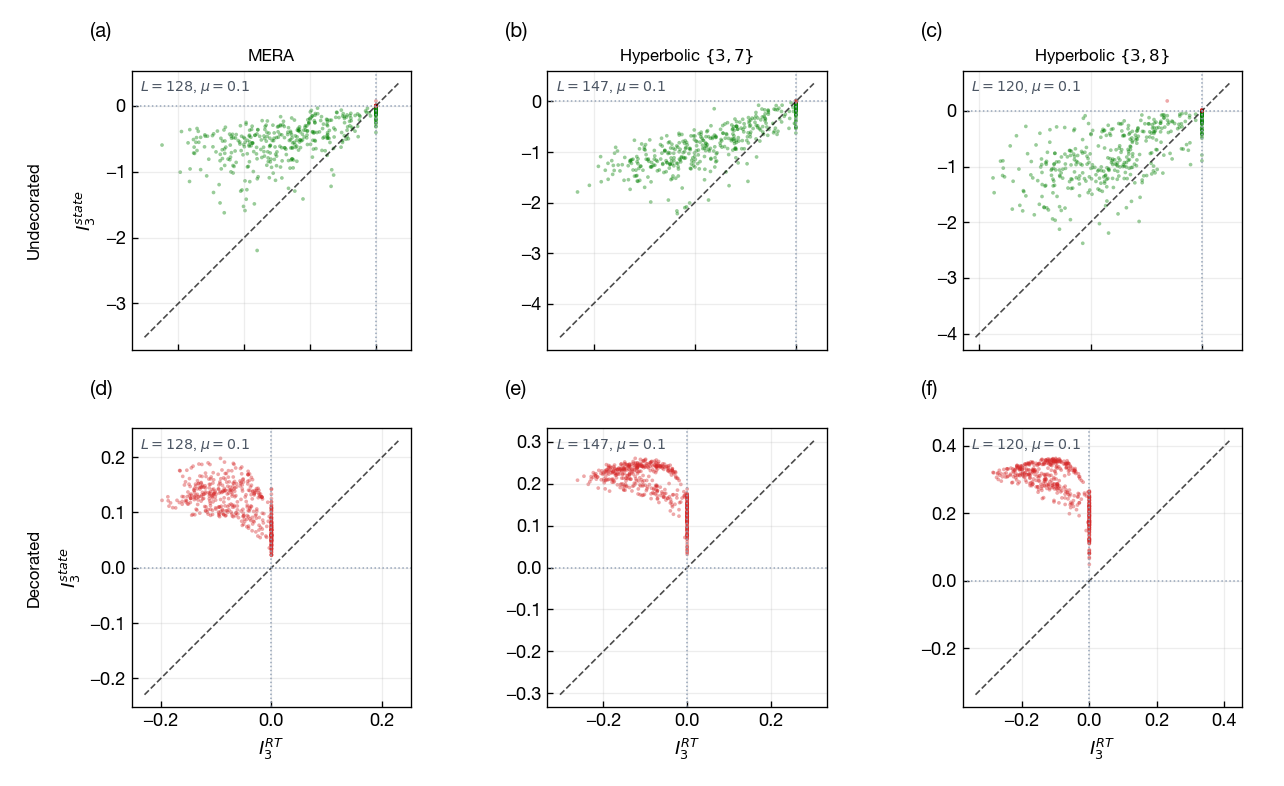

In [3]:
%matplotlib inline
bbox = Bbox.from_bounds(0, 0, 10.7, 6.55)
%config InlineBackend.print_figure_kwargs = {'bbox_inches': bbox}


def plot_i3_comparison(ax, analysis, *, show_ylabel=True, show_xlabel=True):
    result = analysis["result"]
    state_i3 = result["state_i3"]
    rt_i3 = result["rt_i3"]
    finite = np.isfinite(rt_i3) & np.isfinite(state_i3)
    nonpositive = finite & (state_i3 <= 0)
    positive = finite & (state_i3 > 0)
    ax.scatter(
        rt_i3[nonpositive],
        state_i3[nonpositive],
        c=SATISFIED_POINT_STYLE["color"],
        s=SATISFIED_POINT_STYLE["size"],
        alpha=SATISFIED_POINT_STYLE["alpha"],
        edgecolors="none",
    )
    ax.scatter(
        rt_i3[positive],
        state_i3[positive],
        c=VIOLATED_POINT_STYLE["color"],
        s=VIOLATED_POINT_STYLE["size"],
        alpha=VIOLATED_POINT_STYLE["alpha"],
        edgecolors="none",
    )
    span = np.concatenate([rt_i3[finite], state_i3[finite]])
    low = float(np.nanmin(span))
    high = float(np.nanmax(span))
    pad = 0.08 * max(1e-9, high - low)
    ax.plot(
        [low - pad, high + pad],
        [low - pad, high + pad],
        color=REFERENCE_LINE_STYLE["color"],
        lw=REFERENCE_LINE_STYLE["linewidth"],
        ls=REFERENCE_LINE_STYLE["linestyle"],
        alpha=REFERENCE_LINE_STYLE["alpha"],
    )
    ax.axhline(
        0.0,
        color=ZERO_LINE_STYLE["color"],
        lw=ZERO_LINE_STYLE["linewidth"],
        ls=ZERO_LINE_STYLE["linestyle"],
        alpha=ZERO_LINE_STYLE["alpha"],
    )
    ax.axvline(
        0.0,
        color=ZERO_LINE_STYLE["color"],
        lw=ZERO_LINE_STYLE["linewidth"],
        ls=ZERO_LINE_STYLE["linestyle"],
        alpha=ZERO_LINE_STYLE["alpha"],
    )
    boundary_length = analysis["payload"]["boundary_length"]
    ax.text(
        0.03,
        0.97,
        rf"$L={boundary_length}$, $\mu={PRESQUEEZE:g}$",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.5,
        color="#4b5563",
    )
    if show_xlabel:
        ax.set_xlabel(r"$I_3^{RT}$")
    else:
        ax.set_xlabel("")
        ax.tick_params(labelbottom=False)
    if show_ylabel:
        ax.set_ylabel(r"$I_3^{state}$")
    ax.set_box_aspect(1)
    ax.grid(alpha=GRID_STYLE["alpha"])
    return None


fig, axes = plt.subplots(2, len(GRAPH_SYSTEMS), figsize=(bbox.width, bbox.height), squeeze=False)
for col, graph_system in enumerate(GRAPH_SYSTEMS):
    axes[0, col].set_title(graph_system["title"], fontsize=10)
    for row, decoration_row in enumerate(DECORATION_ROWS):
        analysis = analysis_grid[(decoration_row["name"], graph_system["short_label"])]
        plot_i3_comparison(
            axes[row, col],
            analysis,
            show_ylabel=(col == 0),
            show_xlabel=(row == len(DECORATION_ROWS) - 1),
        )

for row, decoration_row in enumerate(DECORATION_ROWS):
    axes[row, 0].text(
        -0.35,
        0.5,
        decoration_row["name"],
        transform=axes[row, 0].transAxes,
        rotation=90,
        ha="center",
        va="center",
        fontsize=10,
    )

panel_labels = [f"({chr(ord('a') + index)})" for index in range(axes.size)]
for label, ax in zip(panel_labels, axes.ravel()):
    ax.text(-0.15, 1.12, label, transform=ax.transAxes, fontsize=subfigure_label_fontsize)

fig.subplots_adjust(left=0.085, right=0.985, bottom=0.10, top=0.91, wspace=0.28, hspace=0.28)

save_figure_with_hash(fig, FIGURE_PATH)
plt.show()

%config InlineBackend.print_figure_kwargs = {'bbox_inches': 'tight'}


## Summary Diagnostics

Print the summary numbers used to check MMI violations and state-versus-RT mismatch.  This table is notebook-only and is not part of the exported figure.

In [4]:
[
    {
        "label": analysis["label"],
        "boundary_length": analysis["payload"]["boundary_length"],
        "central_charge": analysis["result"]["central_charge"],
        "rt_coefficient": analysis["result"]["rt_coefficient"],
        "epsilon_mmi": analysis["result"]["epsilon_mmi"],
        "positive_fraction": analysis["result"]["positive_fraction"],
        "delta_mean": float(np.nanmean(analysis["result"]["delta_i3"])),
        "delta_std": float(np.nanstd(analysis["result"]["delta_i3"])),
    }
    for analysis in analyses
]


[{'label': 'MERA',
  'boundary_length': 128,
  'central_charge': 7.818270445332695,
  'rt_coefficient': 2.6060901484442316,
  'epsilon_mmi': 0.07511851003404146,
  'positive_fraction': 0.042,
  'delta_mean': 0.6218653422036569,
  'delta_std': 0.6711126556285628},
 {'label': 'Hyperbolic $\\{3,7\\}$',
  'boundary_length': 147,
  'central_charge': 10.053060866967366,
  'rt_coefficient': 1.675510144494561,
  'epsilon_mmi': 0.009913064526912763,
  'positive_fraction': 0.024,
  'delta_mean': 0.6837285024285966,
  'delta_std': 0.758596874942504},
 {'label': 'Hyperbolic $\\{3,8\\}$',
  'boundary_length': 120,
  'central_charge': 9.458256888394077,
  'rt_coefficient': 1.5763761480656795,
  'epsilon_mmi': 0.17854354488110147,
  'positive_fraction': 0.044,
  'delta_mean': 0.5989043186114533,
  'delta_std': 0.7347444108796413},
 {'label': 'Decorated mera',
  'boundary_length': 128,
  'central_charge': 0.4907651408181741,
  'rt_coefficient': 0.16358838027272468,
  'epsilon_mmi': 0.19788644460136218